# [[12,2,3]] Twisted Toric Code

In [1]:
import sympy
import svgwrite
from IPython.display import SVG, display
import qeclib
from qeclib.math import is_valid_tableau, stab_to_F2
import numpy as np
import stim
import pymatching
import importlib
from qeclib import PauliNoiseModel
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=200)  # Adjust to a larger value as needed

qubit_positions_24 = {
    "D1": (1, 2),
    "D2": (2, 1),
    "D3": (3, 2),
    "D4": (4, 1),
    "D5": (1, 4),
    "D6": (2, 3),
    "D7": (3, 4),
    "D8": (4, 3),
    "D9": (1, 6),
    "D10": (2, 5),
    "D11": (3, 6),
    "D12": (4, 5),
    "X1": (2, 2),
    "X2": (4, 2),
    "X3": (2, 4),
    "X4": (4, 4),
    "X5": (2, 6),
    "X6": (1, 1),
    "Z1": (3, 1),
    "Z2": (1, 3),
    "Z3": (3, 3),
    "Z4": (1, 5),
    "Z5": (3, 5),
    "Z6": (4, 6),
}

# Order of data qubits in the stabilizers: Top, right, bottom, left
stabilizers_24_TT_generic = [
    ["XXXX", [1,2,5,0], 12], # SX1
    ["XXXX", [3,4,7,2], 13], # SX2
    ["XXXX", [5,6,9,4], 14], # SX3
    ["XXXX", [7,8,11,6], 15], # SX4
    ["XXXX", [9,10,1,8], 16], # SX5
    ["XXXX", [11,0,3,10], 17], # SX6
    ["ZZZZ", [10,3,2,1], 18], # SZ1
    ["ZZZZ", [0,5,4,3], 19], # SZ2
    ["ZZZZ", [2,7,6,5], 20], # SZ3
    ["ZZZZ", [4,9,8,7], 21], # SZ4
    ["ZZZZ", [6,11,10,9], 22], # SZ5
    ["ZZZZ", [8,1,0,11], 23], # SZ6
]
log_X1 = [1,0,0,0,1,0,0,0,1,0,0,0, 0,0,0,0,0,0,0,0,0,0,0,0]
log_Z1 = [0,0,0,0,0,0,0,0,0,0,0,0, 1,0,1,0,1,0,1,0,1,0,1,0]
log_X2 = [0,0,0,0,0,0,0,0,0,0,0,0, 0,1,0,0,0,1,0,0,0,1,0,0]
log_Z2 = [0,1,0,1,0,1,0,1,0,1,0,1, 0,0,0,0,0,0,0,0,0,0,0,0]
log_ops_manual = [log_X1, log_Z1, log_X2, log_Z2]


In [2]:
def sim_readout(op1, op2):
    n = len(op1) // 2
    for i in range(n):
        if (op1[i] == 1 or op1[i+n] == 1) and (op2[i] == 1 or op2[i+n] == 1):
            if op2[i] != op1[i] or op2[i+n] != op1[i+n]:
                return False
    return True

In [3]:
def get_syndrome_circuit(stabilizers, n_qec_cycles: int = 1, n_qubits: int = 0, prep_basis: str = "", qb_coords: dict = None, incl_det_ids: list[int] = None, mode: str = "parallel"):
    def get_qb_coord(i):
        if qb_coords is None:
            return i
        else:
            return f"{qb_coords[i][0]}, {qb_coords[i][1]}"
    ancillas = [stab[2] for stab in stabilizers]
    if incl_det_ids is None:
        incl_det_ids = list(range(len(stabilizers)))
    max_stab_length = 0
    for stab in stabilizers:
        max_stab_length = max(max_stab_length, len(stab[0]))

    circuit_list = []
    for qec_cycle in range(n_qec_cycles):
        circuit_list += (
            ("H", [id for id in ancillas]),
            ("Barrier", []),
        )

        if mode == "sequential":
            for stab in stabilizers:
                for step in range(max_stab_length):
                    if stab[0][step] != "I":
                        circuit_list += (
                            (
                                f"C{stab[0][step]}",
                                [
                                    stab[2],
                                    stab[1][step],
                                ],
                            ),
                        )
                circuit_list += (
                    ("H", stab[2]),
                    ("MR", stab[2]),
                    ("Barrier", []),
                )
        elif mode == "parallel":
            for step in range(max_stab_length):
                for stab in stabilizers:
                    if stab[0][step] != "I":
                        circuit_list += (
                            (
                                f"C{stab[0][step]}",
                                [
                                    stab[2],
                                    stab[1][step],
                                ],
                            ),
                        )
                circuit_list += (("Barrier", []),)

            circuit_list += (
                ("H", ancillas),
                ("MR", ancillas),
            )

        # Create detectors
        if qec_cycle >= 1:
            circuit_list += [
                ("DETECTOR", [f"rec[{-len(stabilizers)*2 + i}]", f"rec[{-len(stabilizers) + i}]"], f"{get_qb_coord(stabilizers[i][2])}, {qec_cycle}")
                for i in range(len(stabilizers))
                if i in incl_det_ids
            ]
        if qec_cycle == 0:
            circuit_list += [
                ("DETECTOR", [f"rec[{-len(stabilizers) + i}]"], f"{get_qb_coord(stabilizers[i][2])}, {qec_cycle}")
                for i in range(len(stabilizers))
                if prep_basis != "" and sim_readout(stab_to_F2([stabilizers[i]], n_qubits)[0], stab_to_F2([[prep_basis, range(n_qubits), None]], n_qubits)[0])
                and i in incl_det_ids
            ]
        circuit_list += (
            ("Barrier", []),
        )

    return circuit_list

In [4]:
def order_stabs(stabs, order = [0, 1, 2, 3]):
    if isinstance(order[0], int):
        order = [order for _ in range(len(stabs))]
    return [
        [stab[0], [stab[1][order[i][0]], stab[1][order[i][1]], stab[1][order[i][2]], stab[1][order[i][3]]], stab[2]]
        for i, stab in enumerate(stabs)
    ]

In [5]:
is_valid_tableau(stab_to_F2(stabilizers_24_TT_generic, 12), [(log_X1, log_Z1), (log_X2, log_Z2)])

d:\local-nobackup\git\qeclibrary\src\qeclib\qeclib\math\symplectic_form.py:285: UserWarning: The system is over-defined, i.e. m + k > n. The stabilizers or logical operators are not independent.
  warnings.warn(


True

In [ ]:
def get_circ(stabilizers, n, n_qec_rounds, init_state, measure_op, observables: list[str] | str, qb_coords, incl_det_ids, stab_mode):
    # Make sure observables is a list
    if isinstance(observables, str):
        observables = [observables]

    measure_op_F2 = stab_to_F2([[measure_op, range(n), None]], n)

    circ = []
    if init_state == "ZZ":
        circ += []
    elif init_state == "XX":
        circ += [
            ("H", range(n)),
        ]
    else:
        raise ValueError("Invalid initial state")
    circ += get_syndrome_circuit(stabilizers, n_qec_rounds, n_qubits=n, prep_basis=measure_op, qb_coords=qb_coords, incl_det_ids=incl_det_ids, mode=stab_mode)

    if "X" in measure_op:
        circ += [("MX", [i for i in range(len(measure_op)) if measure_op[i] == "X"])]
    if "Y" in measure_op:
        circ += [("MY", [i for i in range(len(measure_op)) if measure_op[i] == "Y"])]
    if "Z" in measure_op:
        circ += [("M", [i for i in range(len(measure_op)) if measure_op[i] == "Z"])]

    for stab_index, stab in enumerate(stabilizers):
        if sim_readout(stab_to_F2([stab], n)[0], measure_op_F2[0]) and stab_index in incl_det_ids:
            circ += [("DETECTOR", [f"rec[{-n+stab[1][i]}]" for i in range(len(stab[1])) if stab[0][i] != "I"] + [f"rec[{-n-len(stabilizers) + stab_index}]"], f"{qb_coords[stab[2]][0]}, {qb_coords[stab[2]][1]}, {n_qec_rounds}")]

    for observable in observables:
        circ += [("OBSERVABLE_INCLUDE", [f"rec[{-n+i}]" for i in range(len(observable)) if observable[i] != "I"], 0)]

    return circ

def get_stim_circ(stabilizers, n, n_qec_rounds, init_state, measure_op, qb_coords, incl_det_ids, stab_mode):
    circ = get_circ(stabilizers, n, n_qec_rounds, init_state, measure_op, qb_coords, incl_det_ids, stab_mode)
    noise_model = PauliNoiseModel(0.01)
    stim_circ = qeclib.convert_to_stim(circ, qb_coords, noise_model)
    return stim.Circuit(stim_circ)

Code distance d = 3


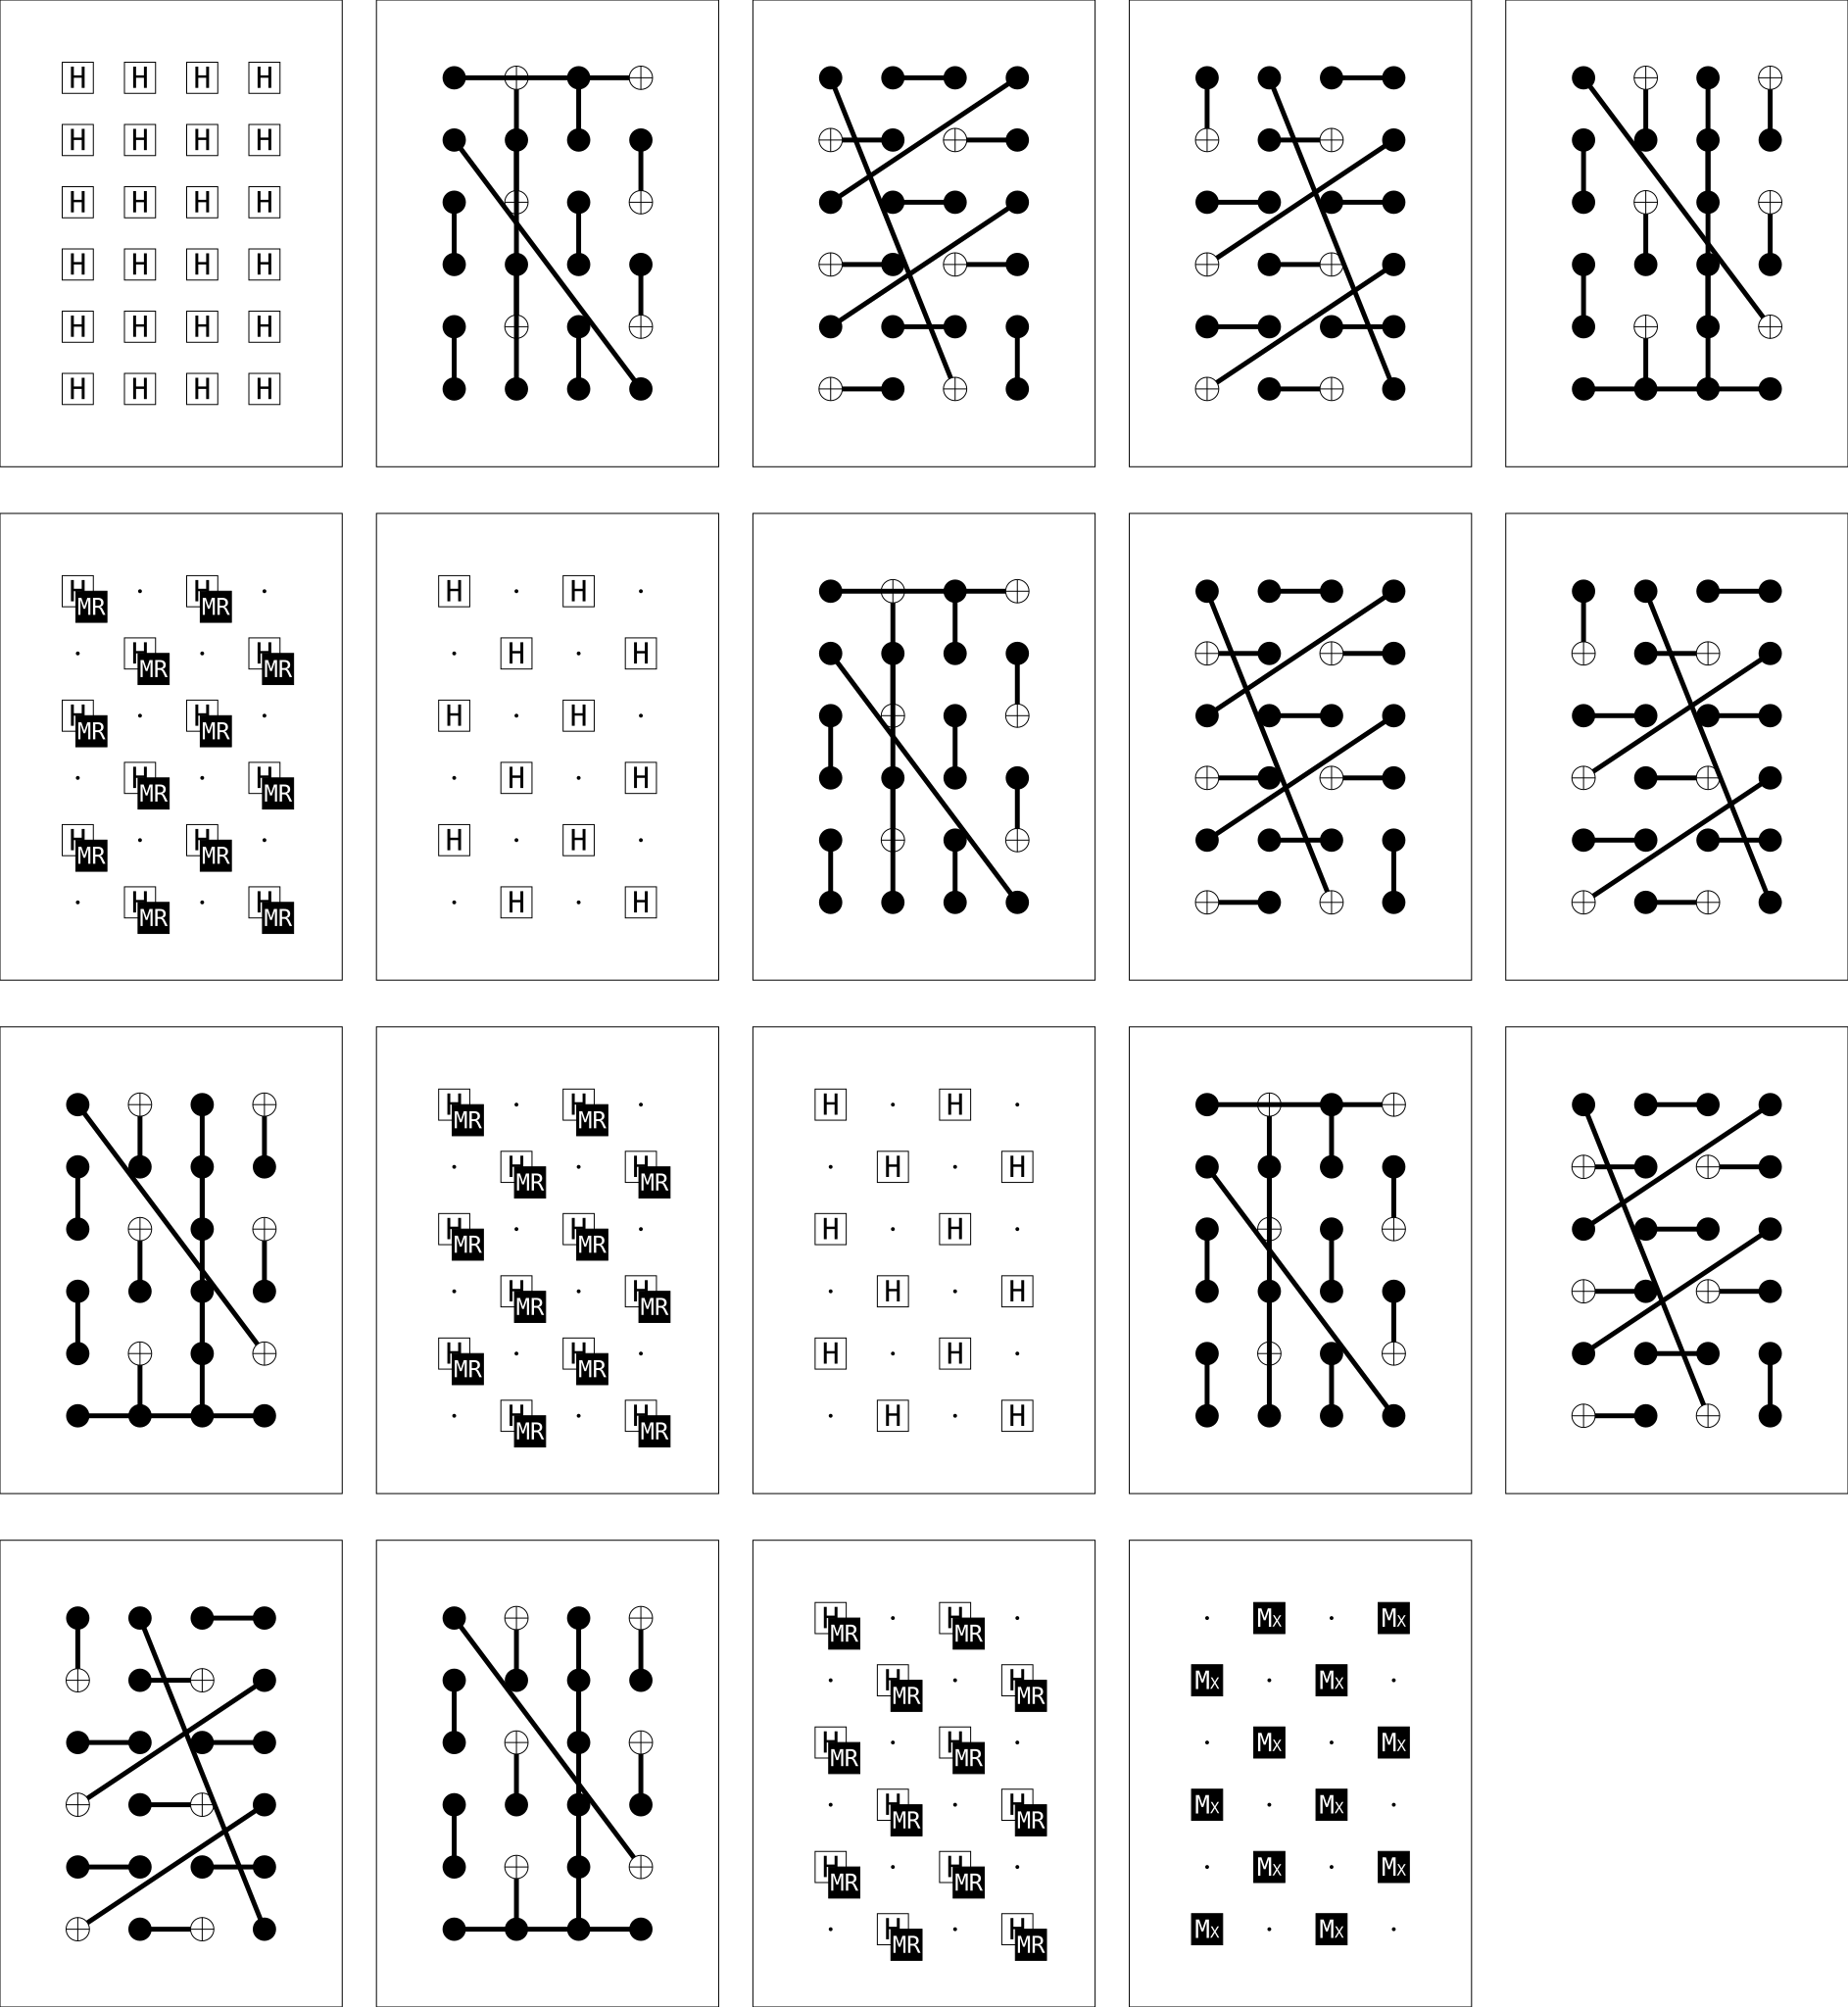

In [ ]:
code = "24TT"
n_qec_rounds = 3
# stab_mode = "sequential"
stab_mode = "parallel"

if code == "24TT":
    n = 12
    # stabilizers = order_stabs(stabilizers_24_TT_generic, [0,3,1,2]) # Works but d=2
    stabilizers = order_stabs(stabilizers_24_TT_generic, [1,0,2,3]) # d=3 !!!
    stabilizers = order_stabs(stabilizers_24_TT_generic, [2,3,1,0]) # d=3 !!!
    incl_det_ids = range(len(stabilizers))
    qb_coords = {}
    for qb, coord in qubit_positions_24.items():
        qb_id = int(qb[1:]) - 1
        if qb[0] == "X":
            qb_id += 12
        if qb[0] == "Z":
            qb_id += 18
        qb_coords[qb_id] = (coord[0], coord[1])
    measure_op = "XXXXXXXXXXXX"
    log_op = "XIIIXIIIXIII"

circ = get_circ(stabilizers, n, n_qec_rounds, "XX", measure_op, qb_coords, incl_det_ids, stab_mode)
stim_circ = get_stim_circ(stabilizers, n, n_qec_rounds, "XX", measure_op, qb_coords, incl_det_ids, stab_mode)
print(f"Code distance d = {len(stim_circ.detector_error_model().shortest_graphlike_error())}")
# print(stim_circ)
stim_circ.without_noise().diagram(type="timeslice-svg")

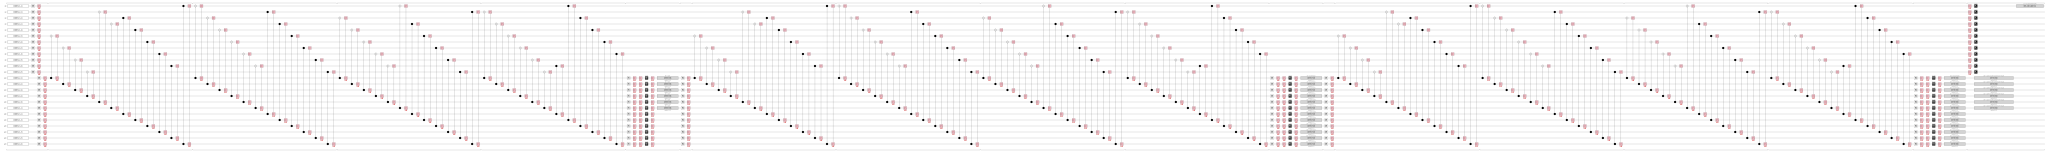

In [8]:
stim_circ.diagram(type="timeline-svg")

In [9]:
print(f"Number of deterministic measurements: {stim_circ.count_determined_measurements()}")
print(f"Number of non-deterministic measurements: {stim_circ.num_measurements - stim_circ.count_determined_measurements()}")
print()
dem = stim_circ.detector_error_model()
print(f"Code distance d = {len(stim_circ.detector_error_model().shortest_graphlike_error())}")
dem.shortest_graphlike_error()

Number of deterministic measurements: 38
Number of non-deterministic measurements: 10

Code distance d = 3


stim.DetectorErrorModel('''
    error(1) D0 D1
    error(1) D0 D5 L0
    error(1) D1 D5
''')

In [10]:
qeclib.print_decoder_performance(circ, p=0.01)

Out of 100000 shots, there were
 • 24198 logical flips (24.2 % of shots),
 • 22741 logical flips predicted by the decoder (22.74 % of shots), and
 • 8108 decoder mistakes (8.11 % of shots)
 • 0 post-selection mistakes (0.0 % of shots)


In [11]:
num_shots = 20000
p_arr = np.logspace(-3, -1, 10)
log_errors = {"raw": [], "dec": [], "pst": []}
for p in p_arr:
    num_raw_err, num_dec_err, num_pst_err, _ = qeclib.get_logical_error_rate(circ, num_shots, p=p)
    log_errors["raw"].append(num_raw_err)
    log_errors["dec"].append(num_dec_err)
    log_errors["pst"].append(num_pst_err)
print("Raw")
print(log_errors["raw"])
print("Decoded")
print(log_errors["dec"])
print("Postselected")
print(log_errors["pst"])

Raw
[0.03205, 0.05115, 0.08355, 0.13185, 0.19845, 0.2892, 0.37625, 0.45885, 0.49975, 0.49705]
Decoded
[0.00075, 0.00335, 0.0069, 0.0192, 0.05365, 0.12335, 0.25335, 0.3983, 0.49125, 0.49995]
Postselected
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


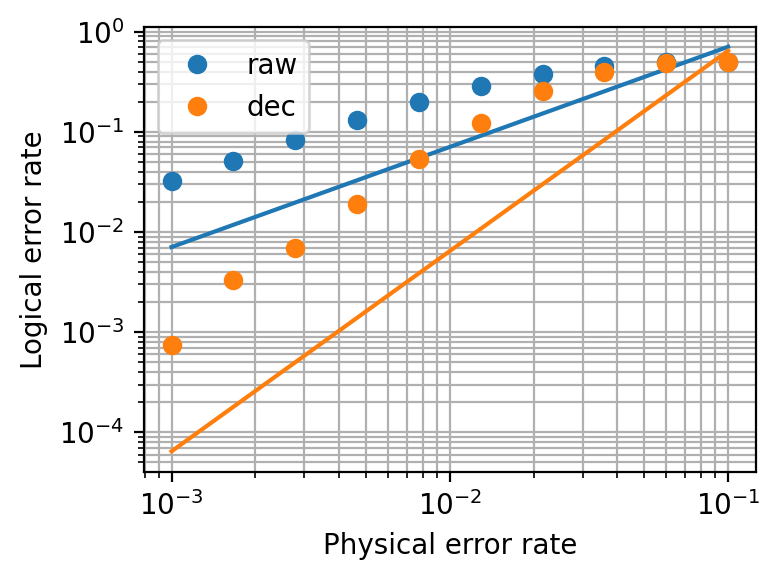

In [12]:
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator, LogLocator

def fit_1_over_x(x, a):
    return a / x

def fit_1_over_x2(x, a):
    return a / x**2

def fit_1_over_x3(x, a):
    return a / x**3

improvement_factor = np.max(p_arr) / np.array(p_arr)
fit_params = {}
fit_covs = {}
function = {"raw": fit_1_over_x, "dec": fit_1_over_x2, "pst": fit_1_over_x3}
for mode in ["raw", "dec", "pst"]:
    popt, pcov = curve_fit(function[mode], improvement_factor, log_errors[mode])
    fit_params[mode] = popt
    fit_covs[mode] = pcov
improvement_factor_fine = np.logspace(np.min(np.log10(improvement_factor)), np.max(np.log10(improvement_factor)), 100)

default_colors = list(plt.rcParams['axes.prop_cycle'].by_key()['color'])

fig, axs = plt.subplots(1, 1, figsize=(4, 3), dpi=200)
for i, mode in enumerate(["raw", "dec"]):
    plt.plot(np.max(p_arr)/np.array(improvement_factor_fine), function[mode](improvement_factor_fine, *fit_params[mode]), color=default_colors[i])
    plt.plot(np.max(p_arr)/np.array(improvement_factor), log_errors[mode], 'o', label=mode, color=default_colors[i])
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.xlabel("Physical error rate")
    plt.ylabel("Logical error rate")

plt.grid(True, which='both')
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=50))
plt.tight_layout()
plt.show()